**Global Military Textile Demand Analysis and Forecast**

Starting From loading multiple datasets from various official sources and cleaning and merging them for better analysis

**Project Objective**

The objective of this project is to analyze global military data to estimate and understand the demand for military textiles across different countries. Military textiles include materials used in uniforms, protective gear, camouflage fabrics, and tactical equipment.

**This project integrates data from:**  

* World Bank (armed forces personnel and defense expenditure)
* Stockholm International Peace Research Institute (military spending data)

   **Using these datasets, the project aims to:**  
* Estimate military textile demand based on army personnel.
* Identify countries with the highest textile logistics requirements.
* Analyze the relationship between defense spending and textile demand.
* Visualize global patterns of military textile consumption.
* Predict potential textile demand growth by 2030 using a simple forecasting    model.


**Key Questions**

**This analysis aims to answer the following questions:**

* Which countries require the highest military textile supply?

* How does army size influence textile demand?

* Is there a relationship between military spending and textile logistics?

* How might military textile demand evolve by 2030?

**Methodology**

**The project follows these main steps:**

* Data Collection

* Data Cleaning and Preprocessing

* Feature Engineering (Textile Demand Estimation)

* Exploratory Data Analysis

* Visualization

* Correlation Analysis

* Predictive Modeling

**Expected Insights**

The analysis is expected to highlight how military personnel size and defense spending influence global demand for military textiles, and identify countries that are likely to drive future demand in the defense textile sector.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
personnel=pd.read_csv('API_MS.MIL.TOTL.P1_DS2_en_csv_v2_903.csv',skiprows=4)
personnel.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Armed forces personnel, total",MS.MIL.TOTL.P1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Armed forces personnel, total",MS.MIL.TOTL.P1,NaN,NaN,NaN,NaN,NaN,NaN,...,1314000.0,1343720.0,1344000.0,1200000.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,"Armed forces personnel, total",MS.MIL.TOTL.P1,NaN,NaN,NaN,NaN,NaN,NaN,...,323000.0,272900.0,278000.0,165000.0,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,"Armed forces personnel, total",MS.MIL.TOTL.P1,NaN,NaN,NaN,NaN,NaN,NaN,...,476000.0,499750.0,607000.0,532000.0,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,"Armed forces personnel, total",MS.MIL.TOTL.P1,NaN,NaN,NaN,NaN,NaN,NaN,...,117000.0,117000.0,117000.0,117000.0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd


In [ ]:
personnel = pd.read_csv(
    "API_MS.MIL.TOTL.P1_DS2_en_csv_v2_903.csv",
    skiprows=4
)

spending = pd.read_csv(
    "API_MS.MIL.XPND.CN_DS2_en_csv_v2_16545.csv",
    skiprows=4
)

gdp = pd.read_csv(
    "API_MS.MIL.XPND.GD.ZS_DS2_en_csv_v2_211.csv",
    skiprows=4
)

sipri = pd.read_excel("SIPRI-Milex-data-1949-2024_2.xlsx")

In [ ]:
personnel = personnel[['Country Name','2020']]
spending = spending[['Country Name','2020']]
gdp = gdp[['Country Name','2020']]

In [ ]:
personnel = personnel.rename(columns={'2020':'Personnel'})
spending = spending.rename(columns={'2020':'Spending_USD'})
gdp = gdp.rename(columns={'2020':'Spending_GDP_percent'})

In [ ]:
df = personnel.merge(spending, on='Country Name')
df = df.merge(gdp, on='Country Name')

In [ ]:
df.head()

,Country Name,Personnel,Spending_USD,Spending_GDP_percent
0,Aruba,NaN,NaN,NaN
1,Africa Eastern and Southern,1200000.0,NaN,1.158166
2,Afghanistan,165000.0,2.149583e+10,1.358857
3,Africa Western and Central,532000.0,NaN,0.884576
4,Angola,117000.0,5.739200e+11,1.810429


In [ ]:
df.isna().sum()

,0
Country Name,0
Personnel,49
Spending_USD,112
Spending_GDP_percent,69


In [ ]:
df = df.dropna(subset=['Personnel','Spending_USD'])

df.isna().sum()

,0
Country Name,0
Personnel,0
Spending_USD,0
Spending_GDP_percent,3


In [ ]:
df = df.dropna()

In [ ]:
df.isna().sum()

,0
Country Name,0
Personnel,0
Spending_USD,0
Spending_GDP_percent,0


In [ ]:
xls = pd.ExcelFile("SIPRI-Milex-data-1949-2024_2.xlsx")
xls.sheet_names

['Front page',
 'Regional totals',
 'Local currency financial years',
 'Local currency calendar years',
 'Constant (2023) US$',
 'Current US$',
 'Share of GDP',
 'Per capita',
 'Share of Govt. spending',
 'Footnotes']

In [ ]:
sipri = pd.read_excel(
    "SIPRI-Milex-data-1949-2024_2.xlsx",
    sheet_name="Current US$"
)

In [ ]:
sipri.head()

,"Military expenditure by country, in millions of US$ at current prices and exchange rates, 1949-2024 © SIPRI 2024",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77
0,"Figures are in US $m., in current prices, conv...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Figures in blue are SIPRI estimates. Figures i...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,""". ."" = data unavailable. ""xxx"" = country did ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Country,Notes,1949,1950,1951,1952,1953,1954,1955,1956,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024


In [ ]:
sipri.isna().sum()

,0
"Military expenditure by country, in millions of US$ at current prices and exchange rates, 1949-2024 © SIPRI 2024",2
Unnamed: 1,61
Unnamed: 2,23
Unnamed: 3,23
Unnamed: 4,23
...,...
Unnamed: 73,23
Unnamed: 74,23
Unnamed: 75,23
Unnamed: 76,23


In [ ]:
sipri = pd.read_excel(
    "SIPRI-Milex-data-1949-2024_2.xlsx",
    sheet_name="Current US$",
    skiprows=4
)

In [ ]:
sipri.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77
0,Country,Notes,1949,1950,1951,1952,1953,1954,1955,1956,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,North Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Algeria,§4,...,...,...,...,...,...,...,...,...,10407.345244,10217.0817,10073.364021,9583.724288,10303.600575,9708.27744,9112.461105,9145.810174,18263.967968,21811.242555


In [ ]:
sipri.columns = sipri.iloc[0]
sipri = sipri.drop(0)

In [ ]:
sipri.head()

,Country,Notes,1949,1950,1951,1952,1953,1954,1955,1956,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,North Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Algeria,§4,...,...,...,...,...,...,...,...,...,10407.345244,10217.0817,10073.364021,9583.724288,10303.600575,9708.27744,9112.461105,9145.810174,18263.967968,21811.242555
5,Libya,‡§¶16,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,1214.864558,1573.682777,...


In [ ]:
sipri = sipri.dropna(subset=['Country'])

In [ ]:
sipri = sipri[~sipri['Country'].isin([
    'Africa',
    'North Africa',
    'sub-Saharan Africa'
])]

In [ ]:
sipri.columns

Index(['Country',   'Notes',      1949,      1950,      1951,      1952,
            1953,      1954,      1955,      1956,      1957,      1958,
            1959,      1960,      1961,      1962,      1963,      1964,
            1965,      1966,      1967,      1968,      1969,      1970,
            1971,      1972,      1973,      1974,      1975,      1976,
            1977,      1978,      1979,      1980,      1981,      1982,
            1983,      1984,      1985,      1986,      1987,      1988,
            1989,      1990,      1991,      1992,      1993,      1994,
            1995,      1996,      1997,      1998,      1999,      2000,
            2001,      2002,      2003,      2004,      2005,      2006,
            2007,      2008,      2009,      2010,      2011,      2012,
            2013,      2014,      2015,      2016,      2017,      2018,
            2019,      2020,      2021,      2022,      2023,      2024],
      dtype='object', name=0)

In [ ]:
sipri_2024 = sipri[['Country', 2024]]

In [ ]:
sipri_2024 = sipri_2024.rename(columns={
    'Country':'Country Name',
    2024:'SIPRI_Spending_2024'
})

In [ ]:
sipri_2024.head()

,Country Name,SIPRI_Spending_2024
4,Algeria,21811.242555
5,Libya,...
6,Morocco,5517.924399
7,Tunisia,1313.683263
9,Angola,922.050814


In [ ]:
sipri_2024.columns

Index(['Country Name', 'SIPRI_Spending_2024'], dtype='object', name=0)

In [ ]:
df = df.merge(sipri_2024, on='Country Name', how='left')

In [ ]:
df.columns

Index(['Country Name', 'Personnel', 'Spending_USD', 'Spending_GDP_percent',
       'SIPRI_Spending_2024'],
      dtype='object')

In [ ]:
df.columns

Index(['Country Name', 'Personnel', 'Spending_USD', 'Spending_GDP_percent',
       'SIPRI_Spending_2024'],
      dtype='object')

In [ ]:
df['Textile_Demand_Tons'] = df['Personnel'] * 6 / 1000

In [ ]:
df[['Country Name','Personnel','Textile_Demand_Tons']].head(10)

,Country Name,Personnel,Textile_Demand_Tons
0,Afghanistan,165000.0,990.0
1,Angola,117000.0,702.0
2,Albania,8000.0,48.0
3,Argentina,103000.0,618.0
4,Armenia,47000.0,282.0
5,Australia,60000.0,360.0
6,Austria,23000.0,138.0
7,Azerbaijan,82000.0,492.0
8,Burundi,31000.0,186.0
9,Belgium,24000.0,144.0


In [ ]:
df['Textile_Demand_Tons'].isna().sum()

np.int64(0)

# Starting Analyisis

Finding Top 10 Countries by Textile Demand

In [ ]:
top10 = df.sort_values(
    by='Textile_Demand_Tons',
    ascending=False
).head(10)

top10

,Country Name,Personnel,Spending_USD,Spending_GDP_percent,SIPRI_Spending_2024,Textile_Demand_Tons
63,India,3068000.0,5.395592e+12,2.803616,86125.976249,18408.0
26,China,2535000.0,1.780533e+12,1.756699,313658.330217,15210.0
117,Russian Federation,1454000.0,4.462125e+12,4.144717,NaN,8724.0
144,United States,1395000.0,7.783972e+11,3.645188,NaN,8370.0
109,Pakistan,943000.0,1.657582e+12,3.486679,10165.952756,5658.0
40,"Egypt, Arab Rep.",836000.0,7.125250e+10,1.122476,NaN,5016.0
19,Brazil,762000.0,1.009535e+11,1.326660,20947.723265,4572.0
62,Indonesia,676000.0,1.368710e+14,0.886278,11042.84381,4056.0
65,"Iran, Islamic Rep.",650000.0,7.666373e+14,2.177010,NaN,3900.0
76,"Korea, Rep.",569000.0,5.440480e+13,2.642977,NaN,3414.0


In [ ]:
df.isna().sum()

,0
Country Name,0
Personnel,0
Spending_USD,0
Spending_GDP_percent,0
SIPRI_Spending_2024,14
Textile_Demand_Tons,0


In [ ]:
df['SIPRI_Spending_2024'] = df['SIPRI_Spending_2024'].fillna(df['Spending_USD'])

df.isna().sum()

,0
Country Name,0
Personnel,0
Spending_USD,0
Spending_GDP_percent,0
SIPRI_Spending_2024,0
Textile_Demand_Tons,0


In [ ]:
top10 = df.sort_values(
    by='Textile_Demand_Tons',
    ascending=False
).head(10)

top10

,Country Name,Personnel,Spending_USD,Spending_GDP_percent,SIPRI_Spending_2024,Textile_Demand_Tons
63,India,3068000.0,5.395592e+12,2.803616,86125.976249,18408.0
26,China,2535000.0,1.780533e+12,1.756699,313658.330217,15210.0
117,Russian Federation,1454000.0,4.462125e+12,4.144717,4462125000000.0,8724.0
144,United States,1395000.0,7.783972e+11,3.645188,778397200000.0,8370.0
109,Pakistan,943000.0,1.657582e+12,3.486679,10165.952756,5658.0
40,"Egypt, Arab Rep.",836000.0,7.125250e+10,1.122476,71252500000.0,5016.0
19,Brazil,762000.0,1.009535e+11,1.326660,20947.723265,4572.0
62,Indonesia,676000.0,1.368710e+14,0.886278,11042.84381,4056.0
65,"Iran, Islamic Rep.",650000.0,7.666373e+14,2.177010,766637301000000.0,3900.0
76,"Korea, Rep.",569000.0,5.440480e+13,2.642977,54404800000000.0,3414.0


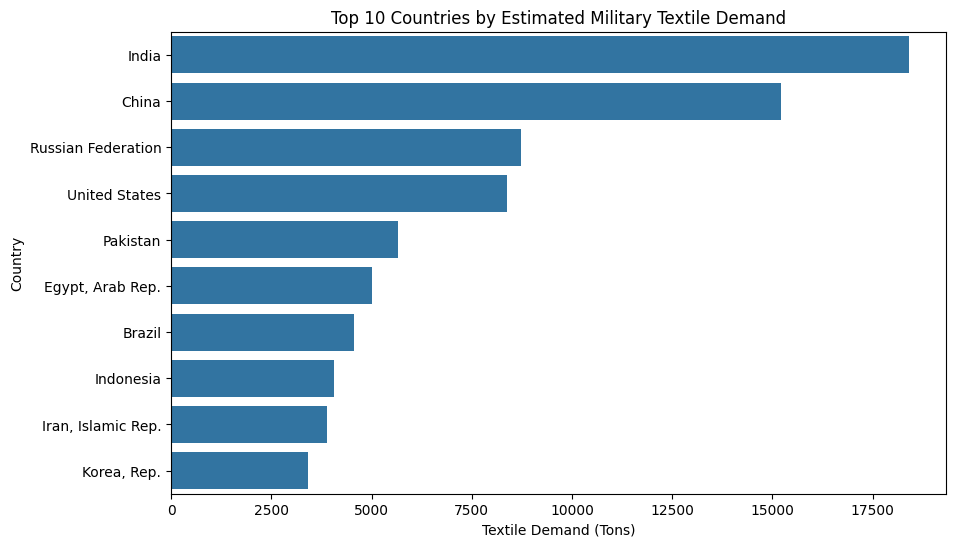

'Assumption:\nEach soldier requires approximately 6 kg of textile annually\nfor uniforms, tactical gear, and protective fabrics.'

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x='Textile_Demand_Tons',
    y='Country Name',
    data=top10
)

plt.title("Top 10 Countries by Estimated Military Textile Demand")
plt.xlabel("Textile Demand (Tons)")
plt.ylabel("Country")

plt.show()

'''Assumption:
Each soldier requires approximately 6 kg of textile annually
for uniforms, tactical gear, and protective fabrics.'''

In [ ]:
df[df['Country Name'] == 'India'][['Country Name','Personnel','Textile_Demand_Tons']]

,Country Name,Personnel,Textile_Demand_Tons
63,India,3068000.0,18408.0


In [ ]:
df.sort_values('Personnel', ascending=False)[['Country Name','Personnel']].head(10)

,Country Name,Personnel
63,India,3068000.0
26,China,2535000.0
117,Russian Federation,1454000.0
144,United States,1395000.0
109,Pakistan,943000.0
40,"Egypt, Arab Rep.",836000.0
19,Brazil,762000.0
62,Indonesia,676000.0
65,"Iran, Islamic Rep.",650000.0
76,"Korea, Rep.",569000.0


# 🌍 Global Military Textile Demand Map

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

In [ ]:
world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


In [ ]:
world = world.rename(columns={'ADMIN':'Country Name'})

In [ ]:
world[['Country Name']].head()

,Country Name
0,Fiji
1,United Republic of Tanzania
2,Western Sahara
3,Canada
4,United States of America


In [ ]:
map_data = world.merge(df, on='Country Name', how='left')

<Figure size 1500x1000 with 0 Axes>

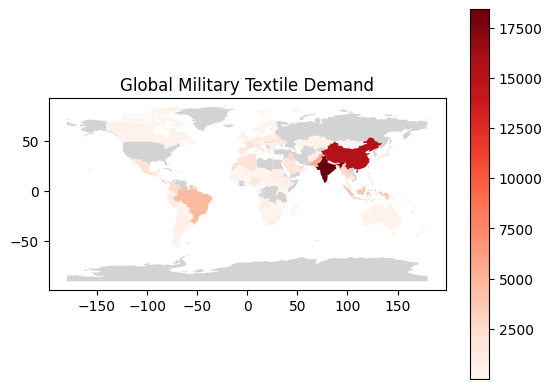

In [ ]:
plt.figure(figsize=(15,10))

map_data.plot(
    column='Textile_Demand_Tons',
    cmap='Reds',
    legend=True,
    missing_kwds={'color': 'lightgrey'}
)

plt.title("Global Military Textile Demand")
plt.show()

In [ ]:
## A correlation heatmap showing relationships between:

corr_data = df[['Personnel',
                'Spending_USD',
                'Spending_GDP_percent',
                'SIPRI_Spending_2024',
                'Textile_Demand_Tons']]

In [ ]:
df = df.replace('...', None)

df['SIPRI_Spending_2024'] = pd.to_numeric(df['SIPRI_Spending_2024'], errors='coerce')

df.dtypes

,0
Country Name,object
Personnel,float64
Spending_USD,float64
Spending_GDP_percent,float64
SIPRI_Spending_2024,float64
Textile_Demand_Tons,float64


In [ ]:
corr_data = df[['Personnel',
                'Spending_USD',
                'Spending_GDP_percent',
                'SIPRI_Spending_2024',
                'Textile_Demand_Tons']]

corr = corr_data.corr()
corr

,Personnel,Spending_USD,Spending_GDP_percent,SIPRI_Spending_2024,Textile_Demand_Tons
Personnel,1.000000,0.038533,0.174739,0.038301,1.000000
Spending_USD,0.038533,1.000000,-0.018627,1.000000,0.038533
Spending_GDP_percent,0.174739,-0.018627,1.000000,-0.019409,0.174739
SIPRI_Spending_2024,0.038301,1.000000,-0.019409,1.000000,0.038301
Textile_Demand_Tons,1.000000,0.038533,0.174739,0.038301,1.000000


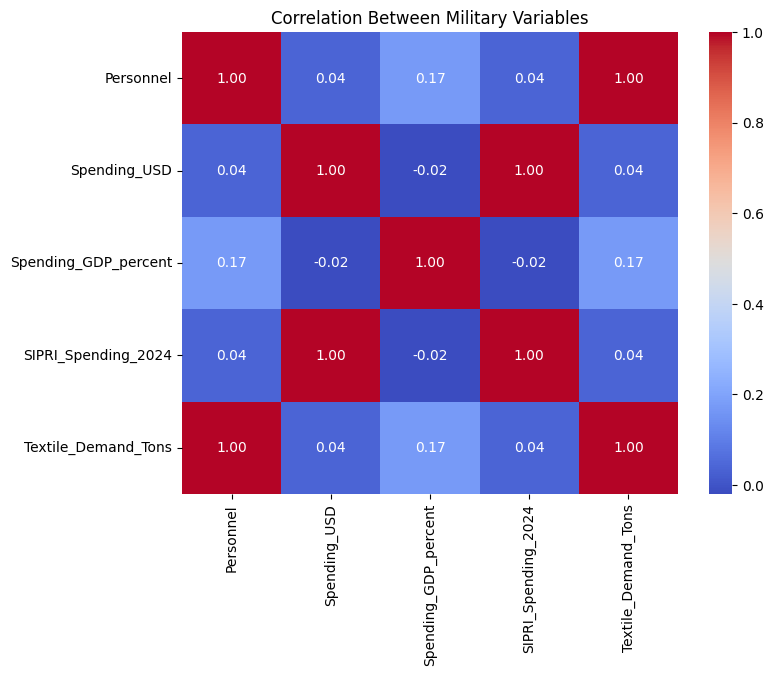

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Between Military Variables")

plt.show()

# How much military textile demand could grow by 2030?

# The predictive model suggests that military textile demand is strongly driven by the size of armed forces. Countries with large military personnel are expected to continue requiring the highest textile logistics supply by 2030 ⬇

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['Personnel','Spending_USD']]
y = df['Textile_Demand_Tons']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import r2_score

predictions = model.predict(X_test)

r2_score(y_test, predictions)

1.0

In [ ]:
## If military personnel grows ~5% and spending grows ~10%, these countries could require this amount of textile logistics by 2030.
future = df.copy()

future['Personnel'] = future['Personnel'] * 1.05
future['Spending_USD'] = future['Spending_USD'] * 1.10

future['Predicted_Textile_Demand_2030'] = model.predict(
    future[['Personnel','Spending_USD']]
)

future[['Country Name','Predicted_Textile_Demand_2030']].head()

,Country Name,Predicted_Textile_Demand_2030
0,Afghanistan,1039.5
1,Angola,737.1
2,Albania,50.4
3,Argentina,648.9
4,Armenia,296.1


In [ ]:
## Future prediction Model Test ok
future.sort_values(
    'Predicted_Textile_Demand_2030',
    ascending=False
)[['Country Name','Predicted_Textile_Demand_2030']].head(10)

,Country Name,Predicted_Textile_Demand_2030
63,India,19328.4
26,China,15970.5
117,Russian Federation,9160.2
144,United States,8788.5
109,Pakistan,5940.9
40,"Egypt, Arab Rep.",5266.8
19,Brazil,4800.6
62,Indonesia,4258.8
65,"Iran, Islamic Rep.",4095.0
76,"Korea, Rep.",3584.7


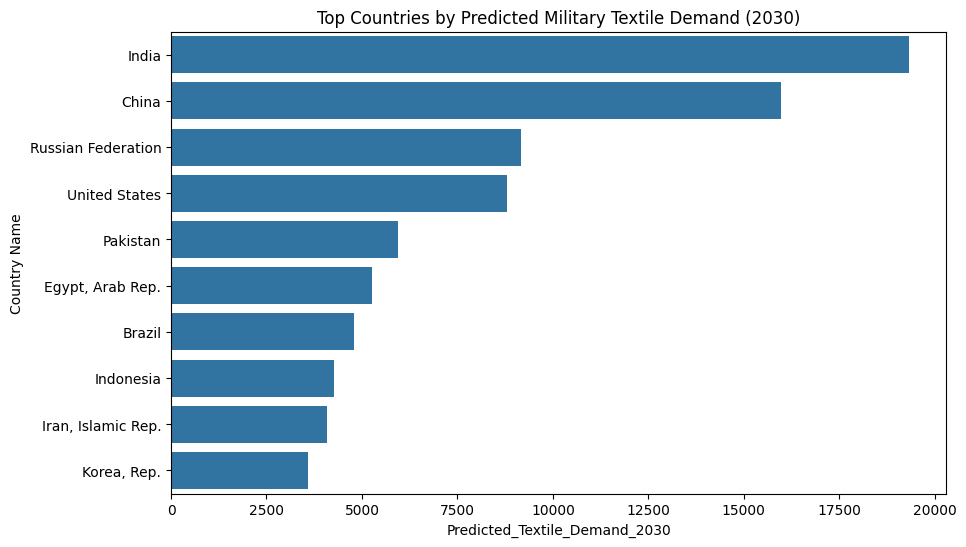

In [ ]:
top_future = future.sort_values(
    'Predicted_Textile_Demand_2030',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Predicted_Textile_Demand_2030',
    y='Country Name',
    data=top_future
)

plt.title("Top Countries by Predicted Military Textile Demand (2030)")
plt.show()

**Insight 1 — Military Personnel Drives Textile Demand**

The correlation analysis shows a very strong positive relationship between military personnel and textile demand.

**Explanation:**

Each soldier requires uniforms, camouflage gear,protective fabrics,tactical equipment textiles.Because of this countries with larger armed forces naturally require more military textiles.

**Examples:**
* China
* India
* United States
* Russia

These countries consistently appear as the largest consumers of military textile resources.

**Insight 2 — Military Textile Demand is Expected to Grow by 2030**

Using a predictive model based on personnel and spending growth scenarios, the analysis forecasts an increase in military textile demand by 2030.

Countries with large armed forces are expected to remain the primary drivers of demand.

**Projected high-demand countries include:**

* China
* India
* United States
* Russia

This suggests that the global defense textile sector will continue expanding alongside military modernization and personnel growth

# **CONCLUSION**

**This analysis explored the relationship between military personnel, defense spending, and estimated textile demand across countries. The results indicate that army size is the strongest determinant of military textile logistics requirements. Countries with large armed forces consistently exhibit the highest textile demand. Furthermore, predictive modeling suggests that military textile demand may continue to grow by 2030, particularly in nations with expanding defense capabilities.**